<a href="https://colab.research.google.com/github/Madhura-55/TimeGAN/blob/main/TimeGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install required libraries
!pip install yfinance -q

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim

# Dataset
import yfinance as yf

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


/tmp/ipykernel_5419/2644929620.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


First 5 values:

Ticker            AAPL
Date                  
2022-01-03  177.939743
2022-01-04  175.681381
2022-01-05  171.008270
2022-01-06  168.153580
2022-01-07  168.319794


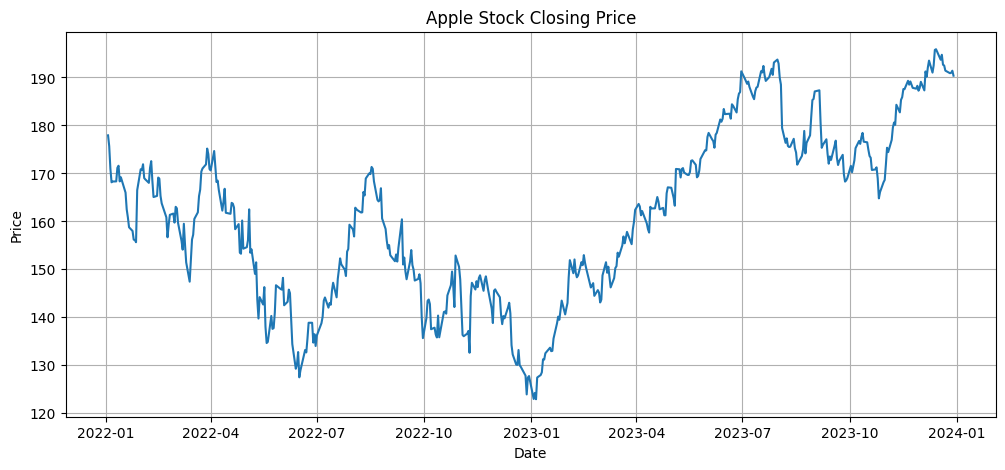

In [3]:
# Download Apple stock data
data = yf.download(
    "AAPL",
    start="2022-01-01",
    end="2024-01-01"
)

# Keep only closing price
prices = data["Close"]

print("First 5 values:\n")
print(prices.head())

# Plot time series
plt.figure(figsize=(12,5))
plt.plot(prices)
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Convert to NumPy array
prices_array = prices.values.reshape(-1, 1)

# Scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_prices = scaler.fit_transform(prices_array)

print("Original Price Range:")
print("Min:", prices_array.min())
print("Max:", prices_array.max())

print("\nScaled Price Range:")
print("Min:", scaled_prices.min())
print("Max:", scaled_prices.max())

Original Price Range:
Min: 122.93354797363281
Max: 195.89263916015625

Scaled Price Range:
Min: 0.0
Max: 1.0000000000000002


In [5]:
# Length of each sequence
sequence_length = 20

# Store sequences
sequences = []

# Create sliding windows
for i in range(len(scaled_prices) - sequence_length):

    sequence = scaled_prices[
        i : i + sequence_length
    ]

    sequences.append(sequence)

# Convert to NumPy array
sequences = np.array(sequences)

print("Sequence Shape:") #(Batch Size,Sequence Length,Features)
print(sequences.shape)

print("\nFirst Sequence:")
print(sequences[0].flatten())



Sequence Shape:
(481, 20, 1)

First Sequence:
[0.75393202 0.72297821 0.6589271  0.61979982 0.622078   0.62234591
 0.66107143 0.66710119 0.62234591 0.63413774 0.59032025 0.54248306
 0.51943481 0.49129604 0.48071013 0.45605399 0.4548485  0.44855041
 0.59742187 0.6570511 ]


In [6]:
class Generator(nn.Module):

    def __init__(self, noise_dim, hidden_dim, sequence_length):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=noise_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        lstm_output, _ = self.lstm(x)

        generated_sequence = self.fc(
            lstm_output
        )

        return generated_sequence


# Hyperparameters
noise_dim = 5
hidden_dim = 32

# Create generator
generator = Generator(
    noise_dim,
    hidden_dim,
    sequence_length
)

print(generator)

Generator(
  (lstm): LSTM(5, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [7]:
class Discriminator(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        lstm_output, _ = self.lstm(x)

        # Use last time step output
        last_output = lstm_output[:, -1, :]

        probability = self.sigmoid(
            self.fc(last_output)
        )

        return probability


# Create discriminator
discriminator = Discriminator(hidden_dim)

print(discriminator)

Discriminator(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Real Sequence  ──► Discriminator ──► 1

Fake Sequence  ──► Discriminator ──► 0

In [9]:
# Convert NumPy data to tensor
from torch.utils.data import TensorDataset, DataLoader
real_data = torch.tensor(
    sequences,
    dtype=torch.float32
)

dataset = TensorDataset(real_data)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

print("Number of batches:",
      len(dataloader))

Number of batches: 16


In [10]:
criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=0.001
)

d_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.001
)

print("Loss and Optimizers Ready")

Loss and Optimizers Ready


In [11]:
# Number of training epochs
epochs = 50

for epoch in range(epochs):

    for real_batch, in dataloader:

        batch_size = real_batch.size(0)

        # ==================================
        # 1. Train Discriminator
        # ==================================

        d_optimizer.zero_grad()

        # Real sequences label = 1
        real_labels = torch.ones(
            batch_size, 1
        )

        # Fake sequences label = 0
        fake_labels = torch.zeros(
            batch_size, 1
        )

        # Real data prediction
        real_output = discriminator(
            real_batch
        )

        real_loss = criterion(
            real_output,
            real_labels
        )

        # Generate fake sequence
        noise = torch.randn(
            batch_size,
            sequence_length,
            noise_dim
        )

        fake_sequence = generator(
            noise
        )

        fake_output = discriminator(
            fake_sequence.detach()
        )

        fake_loss = criterion(
            fake_output,
            fake_labels
        )

        d_loss = real_loss + fake_loss

        d_loss.backward()

        d_optimizer.step()

        # ==================================
        # 2. Train Generator
        # ==================================

        g_optimizer.zero_grad()

        noise = torch.randn(
            batch_size,
            sequence_length,
            noise_dim
        )

        generated_sequence = generator(
            noise
        )

        predictions = discriminator(
            generated_sequence
        )

        g_loss = criterion(
            predictions,
            real_labels
        )

        g_loss.backward()

        g_optimizer.step()

    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"D Loss: {d_loss.item():.4f} "
            f"G Loss: {g_loss.item():.4f}"
        )

print("Training Complete")

Epoch [5/50] D Loss: 1.1117 G Loss: 1.0742
Epoch [10/50] D Loss: 1.4288 G Loss: 0.5967
Epoch [15/50] D Loss: 1.3182 G Loss: 0.7507
Epoch [20/50] D Loss: 1.4038 G Loss: 0.6535
Epoch [25/50] D Loss: 0.9152 G Loss: 1.3340
Epoch [30/50] D Loss: 1.4088 G Loss: 0.6743
Epoch [35/50] D Loss: 1.3597 G Loss: 0.6808
Epoch [40/50] D Loss: 0.5810 G Loss: 1.3038
Epoch [45/50] D Loss: 1.3485 G Loss: 0.7685
Epoch [50/50] D Loss: 1.5233 G Loss: 0.9343
Training Complete


In [12]:
# Generate one synthetic sequence

generator.eval()

with torch.no_grad():

    noise = torch.randn(
        1,
        sequence_length,
        noise_dim
    )

    synthetic_sequence = generator(
        noise
    )

# Convert to NumPy
synthetic_sequence = (
    synthetic_sequence
    .squeeze()
    .numpy()
)

print("Synthetic Sequence Shape:")
print(synthetic_sequence.shape)

print("\nFirst Few Values:")
print(synthetic_sequence[:10])

Synthetic Sequence Shape:
(20,)

First Few Values:
[0.16065039 0.74152577 0.4912752  0.56723714 0.77149045 1.0015247
 0.51426935 0.40332955 0.7781894  0.4022674 ]


In [ ]:
# Take one real sequence

real_sequence = sequences[0].squeeze()

plt.figure(figsize=(12,5))

plt.plot(
    real_sequence,
    label="Real Sequence"
)

plt.plot(
    synthetic_sequence,
    label="Synthetic Sequence"
)

plt.title("Real vs Synthetic Time Series")
plt.xlabel("Time Step")
plt.ylabel("Scaled Value")

plt.legend()
plt.grid(True)

plt.show()

In [23]:
generator.eval()

num_samples = 5

for i in range(num_samples):

    noise = torch.randn(
        1,
        sequence_length,
        noise_dim
    )

    with torch.no_grad():

        fake_seq = generator(
            noise
        )

    fake_seq = (
        fake_seq
        .squeeze()
        .numpy()
    )

    print(f"\nSynthetic Sequence {i+1}")
    print(fake_seq)


Synthetic Sequence 1
[0.41076112 0.7094316  0.44882643 0.2930374  0.27659947 0.15969415
 0.06284505 0.45981848 0.24367774 0.62547183 0.78640723 0.59868765
 0.33811778 0.6208041  0.78516126 0.37272048 0.2557049  0.5487909
 0.24609339 0.64457947]

Synthetic Sequence 2
[0.55287063 0.30475822 0.38946348 0.26624957 0.1328277  0.5142886
 0.88866854 0.5386483  0.4498855  0.88818747 0.4690445  0.36864918
 0.13693993 0.21215676 0.57423    0.3973456  0.43594104 0.2752092
 0.24742384 0.6996814 ]

Synthetic Sequence 3
[0.64788806 0.7461662  0.33446023 0.3486957  0.78209877 0.86875415
 0.51163965 0.31689197 0.33964133 0.3571521  0.3673641  1.0363591
 0.5070663  0.72257936 0.5145139  0.35230678 0.6478164  0.40218675
 0.46870965 0.75677377]

Synthetic Sequence 4
[0.39959407 0.67505825 0.61402047 0.42628717 0.24516016 0.3936236
 0.47843713 0.5129974  0.44506556 0.72835433 0.3197193  0.41085893
 0.27551803 0.61431193 0.6435029  0.5653961  0.4567905  0.3520651
 0.38808575 0.35332823]

Synthetic Sequenc